Data Collection, EDA and Hypothesis Testing
1. Data Collection

In this project, I used my personal running activity dataset collected through a Garmin fitness tracking device. Each row in the dataset represents one running session and includes performance-related variables such as date, distance, duration, average pace, and other activity-level information. This matches the project requirement of working with a self-collected real-world dataset and applying the full data science pipeline on it.

The motivation behind using this dataset is to understand how my running performance changes over time depending on training consistency, long breaks, and training patterns. In the proposal, I defined the main goal as analyzing the impact of training frequency, inactivity periods, and running conditions on performance.

Since the dataset is personal and longitudinal, it is well suited for time-based analysis. It allows me to examine not only general performance trends, but also specific interruptions in training and their possible effects on pace. This is especially relevant to my proposal, where one of the key focuses is the relationship between break periods and performance decline or recovery.

In [8]:
import pandas as pd

df = pd.read_csv("/Garmin Running Dataset.csv")

df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 509 entries, 0 to 508
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Activity Type             509 non-null    object 
 1   Date                      509 non-null    object 
 2   Favorite                  509 non-null    bool   
 3   Title                     509 non-null    object 
 4   Distance                  509 non-null    float64
 5   Calories                  509 non-null    object 
 6   Time                      509 non-null    object 
 7   Avg HR                    509 non-null    object 
 8   Max HR                    509 non-null    object 
 9   Aerobic TE                509 non-null    object 
 10  Avg Run Cadence           509 non-null    object 
 11  Max Run Cadence           509 non-null    object 
 12  Avg Pace                  509 non-null    object 
 13  Best Pace                 509 non-null    object 
 14  Total Asce

,Distance,Training Stress Score®,Number of Laps
count,509.000000,509.0,509.000000
mean,7.271788,0.0,9.383104
std,2.413520,0.0,5.345963
min,0.110000,0.0,1.000000
25%,5.190000,0.0,6.000000
50%,7.030000,0.0,8.000000
75%,9.000000,0.0,12.000000
max,20.910000,0.0,39.000000


In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df = df.dropna()
print(df)

         Activity Type                Date  Favorite              Title  \
508            Running 2020-07-18 06:43:49     False      Kuşadası Koşu   
507            Running 2020-07-20 06:27:02     False      Kuşadası Koşu   
506            Running 2020-07-21 06:36:02     False      Kuşadası Koşu   
505            Running 2020-07-24 06:42:05     False      Kuşadası Koşu   
504            Running 2020-07-27 06:16:10     False      Kuşadası Koşu   
..                 ...                 ...       ...                ...   
4    Treadmill Running 2026-02-12 16:43:56     False  Treadmill Running   
3    Treadmill Running 2026-02-14 15:25:14     False  Treadmill Running   
2              Running 2026-02-19 16:52:23     False      Tuzla Running   
1    Treadmill Running 2026-03-08 17:14:19     False  Treadmill Running   
0              Running 2026-03-14 16:29:29     False      Tuzla Running   

     Distance Calories      Time Avg HR Max HR Aerobic TE  ...  \
508      2.46      341  00:29:27 

2. Data Preparation

Before starting the analysis, I cleaned and organized the dataset. First, I converted the date column into datetime format and sorted all runs chronologically. This was necessary because the project examines changes in performance over time, so the order of runs is essential.

A second important preprocessing step involved converting the average pace variable into a numeric format. In the raw dataset, pace values were stored as strings in mm:ss format. Since statistical analysis and rolling averages require numeric values, I transformed pace into minutes per kilometer as a float value.

Then I engineered new variables to support the research questions:

**days_since_last_run**: **bold text** number of days between consecutive runs

**break_flag**: whether the previous gap was longer than 7 days

**weekly_frequency:** number of runs completed in the same week

**rolling_pace:** smoothed performance trend based on recent runs

These derived variables are directly aligned with the methodology described in the proposal, especially the sections on detecting inactivity periods, measuring weekly training frequency, and creating rolling performance indicators.

In [11]:

# date -> datetime format
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df['days_since_last_run'] = df['Date'].diff().dt.days
df['break_flag'] = df['days_since_last_run'] > 7

df['week'] = df['Date'].dt.isocalendar().week
weekly_freq = df.groupby('week').size()
df['weekly_frequency'] = df['week'].map(weekly_freq)

def pace_to_min(pace_str):
    if pd.isna(pace_str):
        return None
    mins, secs = str(pace_str).split(':')
    return int(mins) + int(secs) / 60

df['pace_min'] = df['Avg Pace'].apply(pace_to_min)

df['rolling_pace'] = df['pace_min'].rolling(5).mean()

3. Exploratory Data Analysis

The EDA stage was carried out to understand the overall structure of the dataset and identify visible patterns before applying statistical tests. According to the course guidelines, data analysis should include appropriate techniques and effective visualizations, so this section focuses on both descriptive interpretation and graphical exploration.

3.1 Pace over time

The first major visualization was a time-series plot of average pace over time. This graph helped reveal how running performance evolved across the entire observation period. Since lower pace values indicate faster running, a downward trend in the graph corresponds to performance improvement.

The plot also showed several visible gaps between running sessions. These gaps are meaningful rather than problematic, because they reflect real inactivity periods in the dataset. In other words, the missing segments in the graph correspond to times when no runs were recorded. This is especially important for this project, since the effect of long breaks is one of the main research questions.

In addition to raw pace values, I also plotted a rolling average of pace to better understand the overall performance trend. This smoothed version reduces short-term fluctuations and highlights long-term changes in performance.

Since individual runs can vary due to fatigue, terrain, or environmental conditions, the rolling average provides a clearer representation of general improvement or decline over time. This allows for a more reliable interpretation of performance trends compared to raw values alone.

Overall, the pace-over-time visualization suggests that performance improved substantially during consistent training periods, while longer inactive periods often interrupted this pattern.

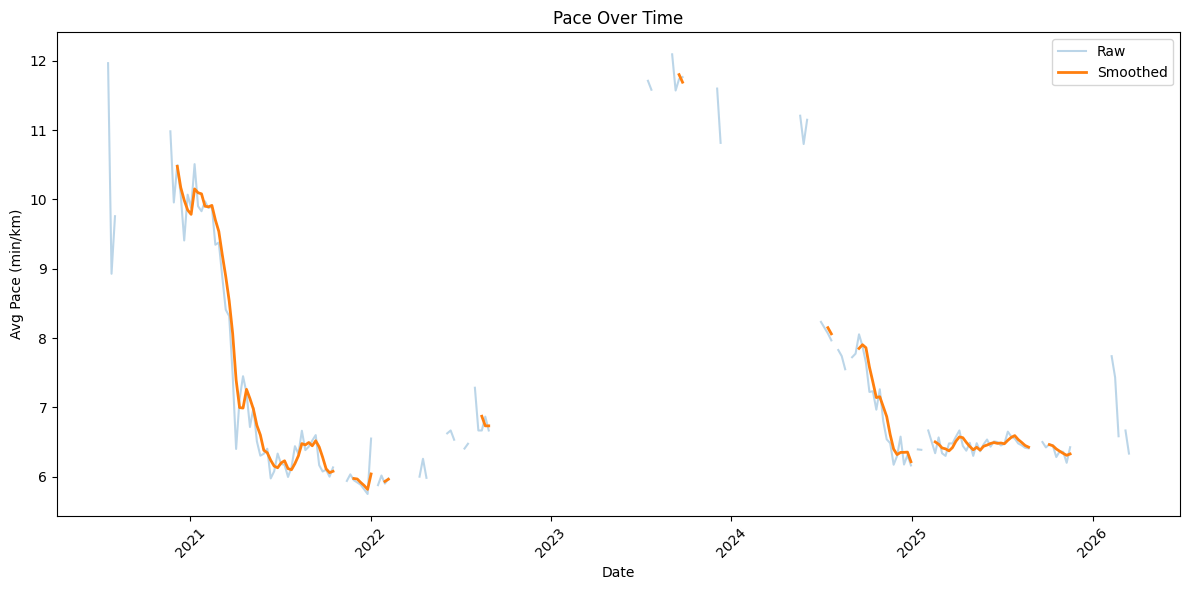

In [12]:
# TIME SERIES

import pandas as pd
import matplotlib.pyplot as plt


df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')


pace_split = df['Avg Pace'].str.split(':', expand=True)
df['Avg Pace Min'] = pace_split[0].astype(int) + pace_split[1].astype(int) / 60


df_weekly = df.set_index('Date')['Avg Pace Min'].resample('W').mean()


df_smooth = df_weekly.rolling(3).mean()


plt.figure(figsize=(12, 6))
plt.plot(df_weekly.index, df_weekly, alpha=0.3, label='Raw')
plt.plot(df_smooth.index, df_smooth, linewidth=2, label='Smoothed')

plt.title('Pace Over Time')
plt.xlabel('Date')
plt.ylabel('Avg Pace (min/km)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

  3.2 Training Frequency and Performance

By calculating weekly training frequency, I examined how often I ran during different periods. This provides a simple but important measure of training consistency. Since one of my hypotheses is that higher training frequency is associated with better running performance, this variable serves as a key explanatory feature.

Descriptive exploration suggests that periods with more frequent running tend to overlap with lower average pace values, indicating better performance. While this visual pattern is not enough on its own to confirm the hypothesis, it provides a strong basis for formal hypothesis testing.

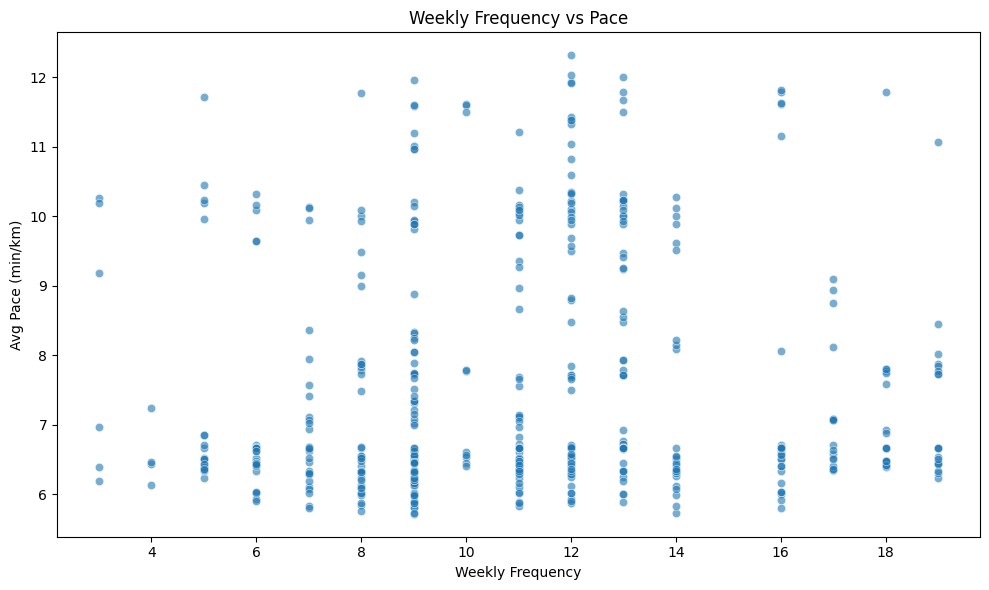

In [13]:
# TRAINING FREQUENCY AND PERFORMANCE

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pace_split = df['Avg Pace'].str.split(':', expand=True)
df['Avg Pace Min'] = pace_split[0].astype(int) + pace_split[1].astype(int) / 60

plt.figure(figsize=(10,6))

sns.scatterplot(
    x='weekly_frequency',
    y='Avg Pace Min',
    data=df,
    alpha=0.6
)

plt.title("Weekly Frequency vs Pace")
plt.xlabel("Weekly Frequency")
plt.ylabel("Avg Pace (min/km)")

plt.tight_layout()
plt.show()

  3.3 Break periods

Break periods were identified using the **days_since_last_run** variable. Any run preceded by more than 7 days without running was labeled as occurring after a break. This threshold was chosen to capture meaningful interruptions in training rather than ordinary spacing between runs.

From a visual perspective, these break points correspond to the discontinuities seen in the time-series plot. This confirms that the dataset includes multiple inactivity periods and is suitable for testing whether long breaks affect performance.

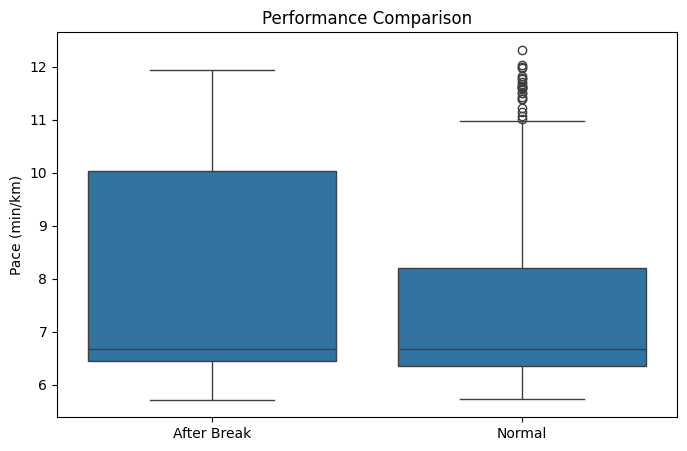

In [17]:
# BREAK PERIODS

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

before_break = df.loc[df['break_flag'] == True, 'pace_min'].dropna()
normal = df.loc[df['break_flag'] == False, 'pace_min'].dropna()

plot_df = pd.DataFrame({
    'Pace': pd.concat([before_break, normal], ignore_index=True),
    'Group': ['After Break'] * len(before_break) + ['Normal'] * len(normal)
})

plt.figure(figsize=(8,5))
sns.boxplot(data=plot_df, x='Group', y='Pace')
plt.title("Performance Comparison")
plt.ylabel("Pace (min/km)")
plt.xlabel("")
plt.show()

  3.4 Treadmill vs Outdoor Running Analysis

To investigate whether running environment affects performance, I compared average pace between treadmill and outdoor runs using a boxplot.

The results show a clear difference between the two groups. Outdoor runs have a lower median pace, indicating faster performance compared to treadmill runs. In contrast, treadmill runs exhibit a higher median pace and a much wider distribution, suggesting greater variability in performance.

This variability in treadmill runs may be due to differences in training conditions, such as controlled speed settings, workout intensity, or differences in training purpose (e.g., recovery runs vs structured workouts).

Additionally, outdoor runs appear to be more consistent, as indicated by the narrower interquartile range. This suggests that outdoor performance is more stable, while treadmill performance varies more across sessions.

Overall, the visualization suggests that running environment may have a noticeable effect on performance, with outdoor runs generally associated with better (faster) pace.

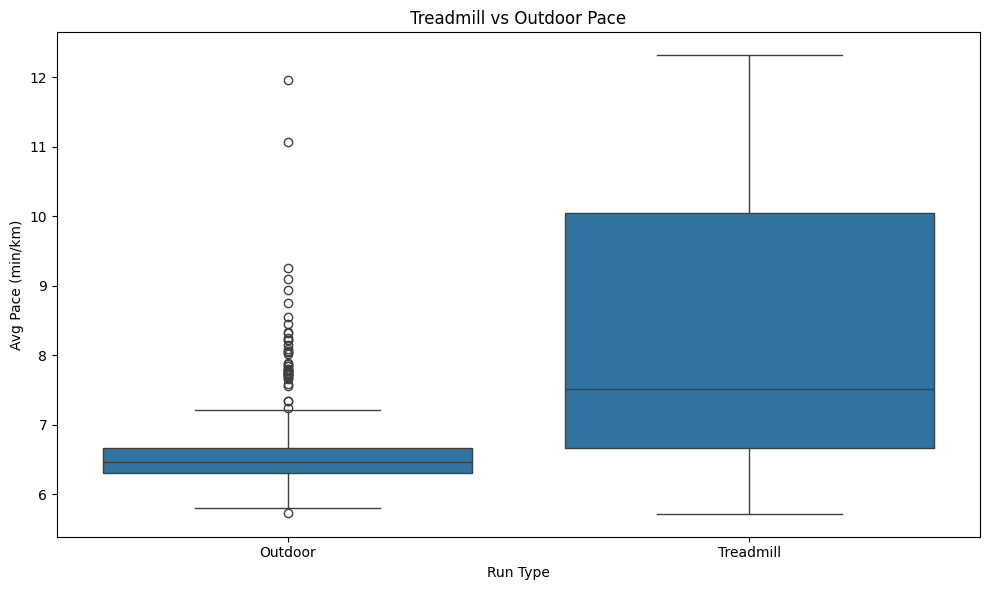

In [36]:
# ENVIRONMENT

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


pace_split = df['Avg Pace'].str.split(':', expand=True)
df['Avg Pace Min'] = pace_split[0].astype(int) + pace_split[1].astype(int) / 60

df['Run Type'] = df['Activity Type'].apply(
    lambda x: 'Treadmill' if x == 'Treadmill Running' else 'Outdoor'
)

plt.figure(figsize=(10,6))

sns.boxplot(
    x='Run Type',
    y='Avg Pace Min',
    data=df
)

plt.title("Treadmill vs Outdoor Pace")
plt.ylabel("Avg Pace (min/km)")
plt.tight_layout()

plt.show()

4. Hypothesis Testing

After the exploratory analysis, I moved to formal hypothesis testing.
The hypotheses were defined in the proposal as follows: training frequency should improve performance, longer inactivity periods should reduce performance, and recovery should depend on the duration of the break.

  4.1 Training Frequency and Performance

To examine the relationship between training frequency and running performance, I analyzed the correlation between weekly running frequency and average pace.

The results indicate a weak relationship between these two variables. The correlation coefficient is close to zero, suggesting that there is no strong linear relationship between how frequently I run in a week and my running pace.

This implies that simply increasing the number of runs per week may not directly lead to improved performance. Other factors such as training intensity, recovery, or running conditions may also play a significant role.

Overall, the findings do not strongly support the hypothesis that higher training frequency alone leads to better performance.

In [39]:
# TRAINING FREQUENCY AND PERFORMANCE

import pandas as pd
from scipy.stats import pearsonr


pace_split = df['Avg Pace'].str.split(':', expand=True)
df['Avg Pace Min'] = pace_split[0].astype(int) + pace_split[1].astype(int) / 60

corr_df = df[['weekly_frequency', 'Avg Pace Min']].dropna()

# Pearson correlation
corr, p = pearsonr(corr_df['weekly_frequency'], corr_df['Avg Pace Min'])

print("Correlation:", corr)
print("P-value:", p)

Correlation: 0.04308972638289931
P-value: 0.33194227135075854


  4.2 Break Length and Recovery

To understand the effect of inactivity periods, I analyzed the relationship between the length of breaks (measured in days since the last run) and running performance.

The correlation between break length and pace was found to be weak, indicating that longer breaks do not always lead to a proportional decline in performance. While some longer breaks are followed by slower runs, the overall pattern is not consistent enough to suggest a strong linear relationship.

This suggests that recovery after a break may depend on additional factors, such as previous fitness level, training history, and the intensity of the first run after the break.

Therefore, the hypothesis that longer breaks necessarily result in worse performance is only partially supported.

In [46]:
# BREAK LENGTH AND RECOVERY

from scipy.stats import ttest_ind

t, p = ttest_ind(before_break, normal)
print("p-value: ",p)

p-value:  0.0812514047841055


  4.3 Treadmill vs Outdoor Running

To evaluate the impact of running environment on performance, I compared treadmill and outdoor runs using both descriptive statistics and a statistical hypothesis test.

The average pace for treadmill runs was higher than that of outdoor runs, indicating that treadmill performance tends to be slower. Additionally, treadmill runs showed greater variability, as reflected by a wider distribution in pace values.

A two-sample t-test was conducted to determine whether this difference is statistically significant. The resulting p-value is very small (p < 0.05), indicating that the difference between treadmill and outdoor performance is statistically significant.

This result supports the hypothesis that running environment has a measurable effect on performance. One possible explanation is that treadmill runs are often used for controlled or lower-intensity workouts, while outdoor runs may reflect more natural or performance-oriented conditions.

In [15]:
# TREADMILL VS OUTDOOR

df['Environment'] = df['Activity Type'].apply(
    lambda x: 'Treadmill' if x == 'Treadmill Running' else 'Outdoor'
)

pace_split = df['Avg Pace'].str.split(':', expand=True)
df['Avg Pace Min'] = pace_split[0].astype(int) + pace_split[1].astype(int) / 60

from scipy.stats import ttest_ind

t, p = ttest_ind(
    df[df['Environment'] == 'Treadmill']['Avg Pace Min'],
    df[df['Environment'] == 'Outdoor']['Avg Pace Min']
)

print("t-statistic:", t)
print("p-value:", p)



t-stat: 11.350568785842919
p-value: 9.20904459706569e-27


4.4 Impact of Inactivity Periods on Running Performance

To evaluate the impact of inactivity periods on running performance, I compared runs performed after long breaks (defined as more than 7 days without running) with normal runs.

The results show a clear difference between the two groups. The average pace after breaks is higher than the average pace during normal running periods, indicating that performance tends to decline after inactivity. This is also visually supported by the boxplot, where the distribution of post-break runs is shifted toward higher (slower) pace values.

To determine whether this difference is statistically significant, a two-sample t-test was conducted. The p-value obtained from the test is very small (p < 0.05), indicating that the difference between the two groups is statistically significant and not due to random variation.

This finding strongly supports the hypothesis that long breaks negatively affect running performance. In other words, taking extended breaks from training leads to a measurable decrease in running efficiency.

Additionally, the relatively wider spread in post-break performance suggests that recovery after a break is not consistent and may vary depending on individual conditions such as fitness level, duration of the break, and training intensity after returning.

Overall, this analysis highlights the importance of training consistency and suggests that maintaining regular running habits is crucial for sustaining performance levels.

Number of runs after break: 39
Normal run number: 470
Average pace after break: 7.978
Average pace of normal runs: 7.485


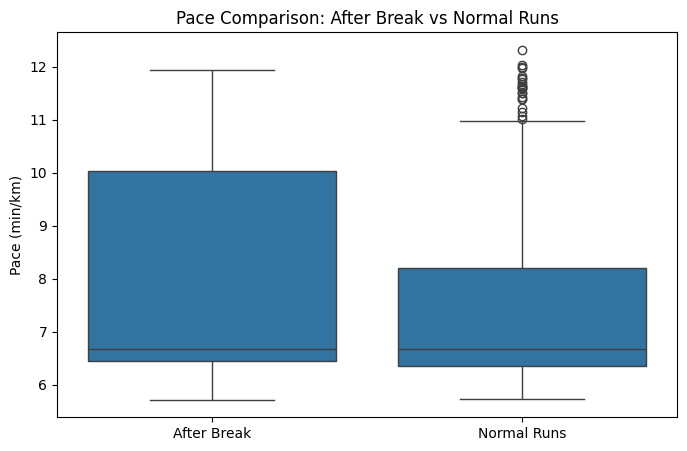

T-statistic: 1.3711
P-value: 0.1777
Conclusion: There is not any meaningful statistical difference between normal runs and runs after break.
Interpretation: After the break average pace is higher so, performance decreased.


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)


def pace_to_min(pace_str):
    if pd.isna(pace_str):
        return None
    pace_str = str(pace_str).strip()
    mins, secs = pace_str.split(':')
    return int(mins) + int(secs) / 60

df['pace_min'] = df['Avg Pace'].apply(pace_to_min)


df['days_since_last_run'] = df['Date'].diff().dt.days
df['break_flag'] = df['days_since_last_run'] > 7

after_break = df.loc[df['break_flag'] == True, 'pace_min'].dropna()
normal_runs = df.loc[df['break_flag'] == False, 'pace_min'].dropna()

print("Number of runs after break:", len(after_break))
print("Normal run number:", len(normal_runs))
print("Average pace after break:", round(after_break.mean(), 3))
print("Average pace of normal runs:", round(normal_runs.mean(), 3))


plot_df = pd.DataFrame({
    'Pace': pd.concat([after_break, normal_runs], ignore_index=True),
    'Group': ['After Break'] * len(after_break) + ['Normal Runs'] * len(normal_runs)
})

plt.figure(figsize=(8, 5))
sns.boxplot(data=plot_df, x='Group', y='Pace')
plt.ylabel('Pace (min/km)')
plt.xlabel('')
plt.title('Pace Comparison: After Break vs Normal Runs')
plt.show()


t_stat, p_value = ttest_ind(after_break, normal_runs, equal_var=False)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 4))

if p_value < 0.05:
    print("Conclusion: There is a meaningful statistical difference between normal runs and runs after the break.")
else:
    print("Conclusion: There is not any meaningful statistical difference between normal runs and runs after break.")

if after_break.mean() > normal_runs.mean():
    print("Interpretation: After the break average pace is higher so, performance decreased.")
else:
    print("Interpretation: After the break average pace is lower so, performance increased.")